# Velocity Comparisons

In [12]:
from __future__ import annotations

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import xarray as xr
from colorama import Style
from IPython.display import HTML, display
from ipywidgets import widgets
from scipy.stats import describe, ttest_ind_from_stats

HTML("""
    <style>
    .cell-output-ipywidget-background{background: transparent !important;}
    .widget-label{color: white !important;}
    </style>
""")

In [2]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
VEL_PATH_V1 = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise.nc"
)
VEL_PATH_V5 = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise_v5.nc"
)

In [3]:
velocity = xr.open_dataset(VEL_PATH_V1)
velocity_v1 = velocity.copy().resample(time="1h").mean()
velocity_v5 = xr.open_dataset(VEL_PATH_V5).resample(time="1h").mean(skipna=True)

## Velocity Variable Comparisons

In [4]:
depth = widgets.Dropdown(
    options=velocity.depth.values,
    value=velocity.depth.values[0],
    description="Depth:",
)
display(depth)
variable = widgets.Dropdown(
    options=["u", "u_filt", "cs", "cs_proj"],
    value="u",
    description="Variable:",
)
display(variable)

Dropdown(description='Depth:', options=(np.float32(0.0), np.float32(2.0), np.float32(4.0), np.float32(6.0), np…

Dropdown(description='Variable:', options=('u', 'u_filt', 'cs', 'cs_proj'), value='u')

<Figure size 1500x1000 with 0 Axes>

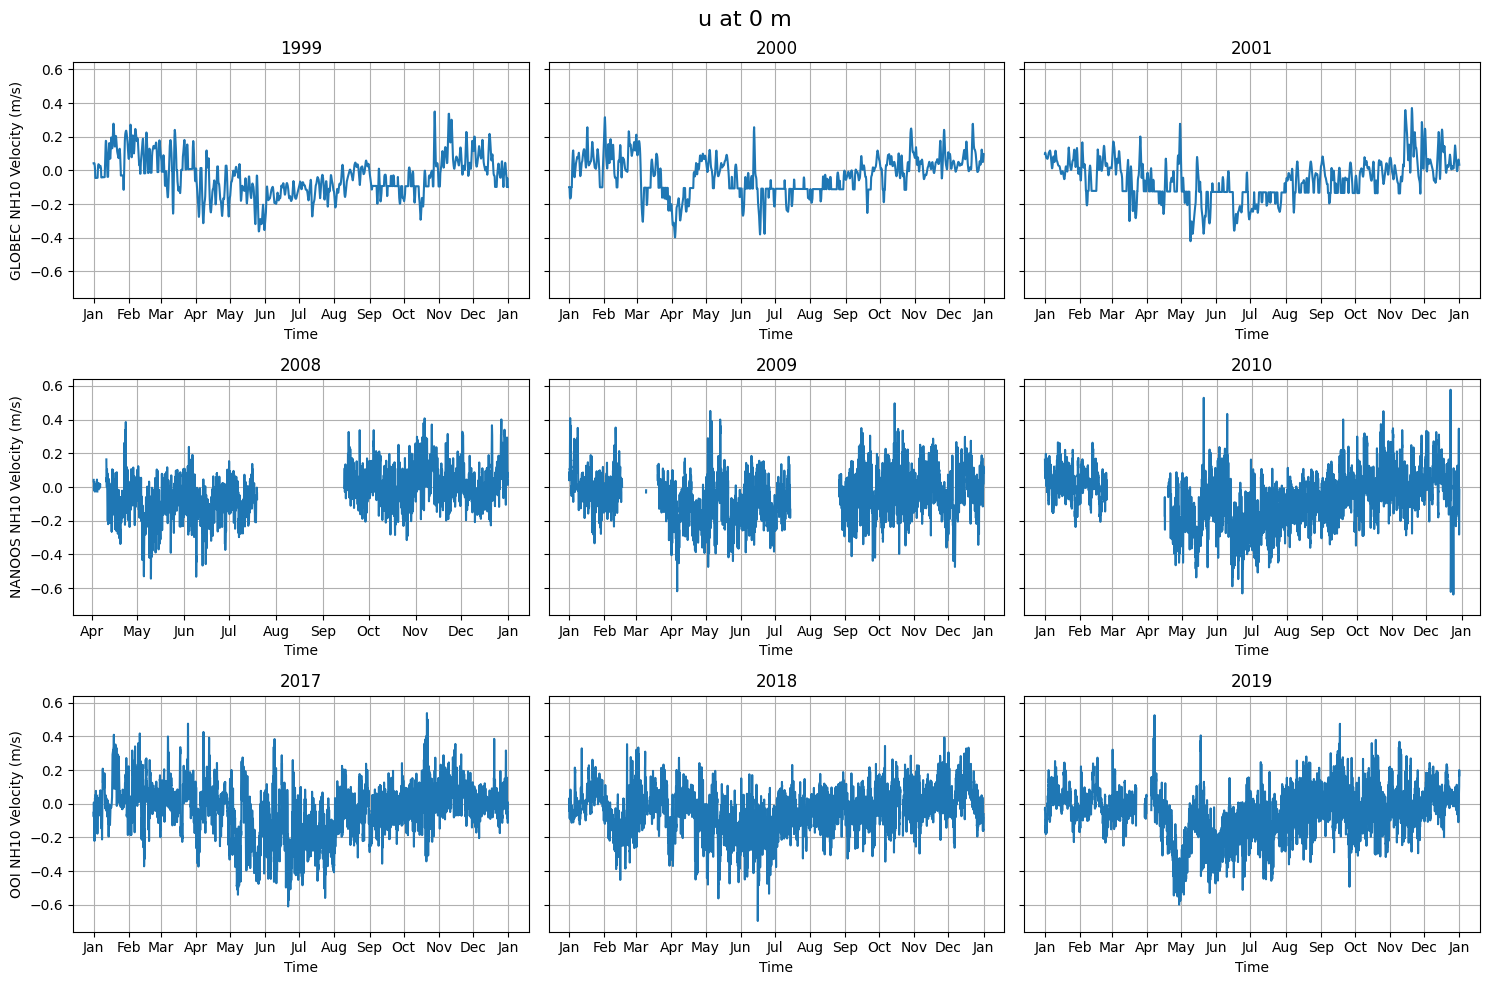

In [5]:
plt.subplots(3, 3, figsize=(15, 10), sharey=True)


def plot_velocity(depth, variable):
    plt.clf()
    plt.suptitle(f"{variable} at {depth} m")
    fig, (axs1, axs2, axs3) = plt.subplots(3, 3, figsize=(15, 10), sharey=True)
    for i, year in enumerate(range(1999, 2002)):
        ax = axs1[i]
        ax.plot(
            velocity.time.sel(time=str(year)),
            velocity[variable].sel(depth=depth).sel(time=str(year)),
            label=variable,
        )
        ax.set_title(str(year))
        axs1[0].set_ylabel("GLOBEC NH10 Velocity (m/s)")
    for i, year in enumerate(range(2008, 2011)):
        ax = axs2[i]
        ax.plot(
            velocity.time.sel(time=str(year)),
            velocity[variable].sel(depth=depth).sel(time=str(year)),
            label=variable,
        )
        ax.set_title(str(year))
        axs2[0].set_ylabel("NANOOS NH10 Velocity (m/s)")
    for i, year in enumerate(range(2017, 2020)):
        ax = axs3[i]
        ax.plot(
            velocity.time.sel(time=str(year)),
            velocity[variable].sel(depth=depth).sel(time=str(year)),
            label=variable,
        )
        ax.set_title(str(year))
        axs3[0].set_ylabel("OOI NH10 Velocity (m/s)")
    for ax in zip(axs1, axs2, axs3):
        for a in ax:
            a.xaxis.set_major_locator(mdates.MonthLocator())
            a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
            a.set_xlabel("Time")
            a.grid(True)
    fig.suptitle(f"{variable} at {depth:.0f} m", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_velocity(depth.value, variable.value)

SELECTED DEPTH:   0 m
SELECTED VARIABLE:u


,Mean,Variance,Range,Skewness,Kurtosis
Nanoos (2005-2015),-0.0632,0.0195,"[-0.66, 0.59]",-0.1113,0.6766
OOI (2015-2021),-0.0501,0.0211,"[-0.73, 0.73]",-0.3033,0.6952
Globec (1997-2004),-0.0400,0.0148,"[-0.46, 0.37]",-0.0390,0.1340


Globec vs Nanoos: t-statistic = 2.87, p-value = 0.0042
OOI vs Nanoos:    t-statistic = 1.47, p-value = 0.1415
Globec vs OOI:    t-statistic = 1.28, p-value = 0.1997


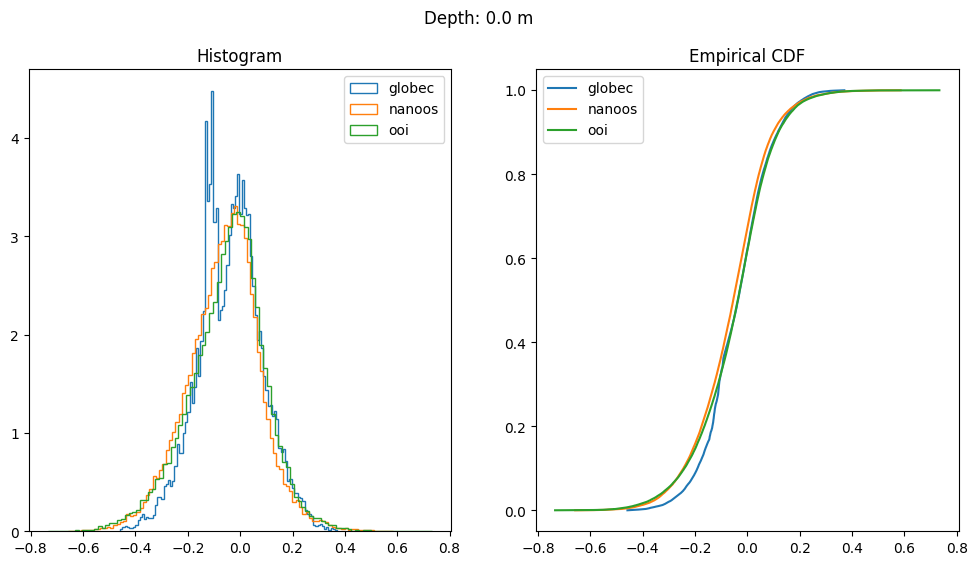

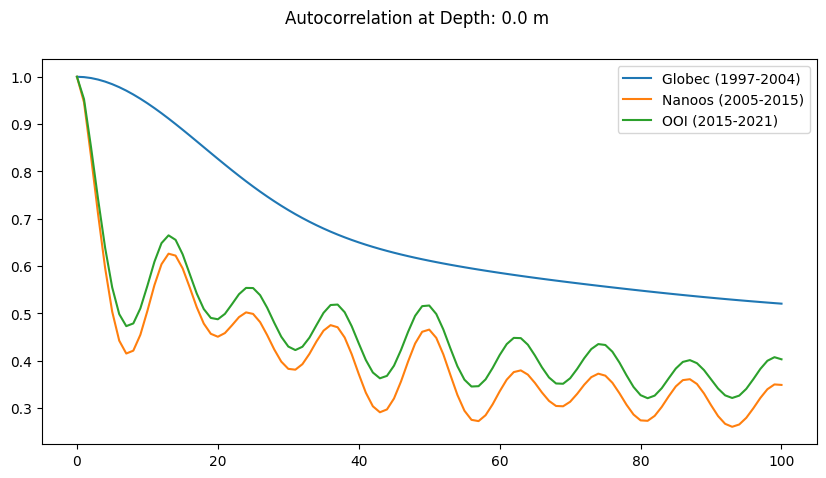

In [6]:
print(f"{Style.BRIGHT}{'SELECTED DEPTH:':<18}{depth.value:.0f} m{Style.RESET_ALL}")
print(f"{Style.BRIGHT}{'SELECTED VARIABLE:':<18}{variable.value}{Style.RESET_ALL}")

globec = (
    velocity[variable.value]
    .where(velocity.time < np.datetime64("2005-01-01"), drop=True)
    .dropna(dim="time")
    .dropna(dim="depth")
    .sel(depth=depth.value)
)
nanoos = (
    velocity[variable.value]
    .where(
        (velocity.time > np.datetime64("2005-01-01"))
        & (velocity.time < np.datetime64("2015-01-01")),
        drop=True,
    )
    .dropna(dim="time")
    .dropna(dim="depth")
    .sel(depth=depth.value)
)
ooi = (
    velocity[variable.value]
    .where((velocity.time > np.datetime64("2015-01-01")))
    .dropna(dim="time")
    .dropna(dim="depth")
    .sel(depth=depth.value)
)
nanoos_ecdf = sm.distributions.empirical_distribution.ECDF(nanoos.values)
ooi_ecdf = sm.distributions.empirical_distribution.ECDF(ooi.values)
globec_ecdf = sm.distributions.empirical_distribution.ECDF(globec.values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
ax1.hist(globec.values, bins=100, density=True, histtype="step", label="globec")
ax1.hist(nanoos.values, bins=100, density=True, histtype="step", label="nanoos")
ax1.hist(ooi.values, bins=100, density=True, histtype="step", label="ooi")
ax1.legend()
ax2.plot(globec_ecdf.x, globec_ecdf.y, label="globec")
ax2.plot(nanoos_ecdf.x, nanoos_ecdf.y, label="nanoos")
ax2.plot(ooi_ecdf.x, ooi_ecdf.y, label="ooi")
ax2.legend()
fig.suptitle(f"Depth: {depth.value} m")
ax1.set_title("Histogram")
ax2.set_title("Empirical CDF")

df = pd.DataFrame(
    data={
        "Mean": [
            describe(nanoos.values).mean,
            describe(ooi.values).mean,
            describe(globec.values).mean,
        ],
        "Variance": [
            describe(nanoos.values).variance,
            describe(ooi.values).variance,
            describe(globec.values).variance,
        ],
        "Range": [
            describe(nanoos.values).minmax,
            describe(ooi.values).minmax,
            describe(globec.values).minmax,
        ],
        "Skewness": [
            describe(nanoos.values).skewness,
            describe(ooi.values).skewness,
            describe(globec.values).skewness,
        ],
        "Kurtosis": [
            describe(nanoos.values).kurtosis,
            describe(ooi.values).kurtosis,
            describe(globec.values).kurtosis,
        ],
    },
    index=["Nanoos (2005-2015)", "OOI (2015-2021)", "Globec (1997-2004)"],
)
display(
    HTML(
        df.to_html(
            index=True,
            justify="left",
            border=0,
            classes=["dataframe", "table"],
            float_format="{:.4f}".format,
            formatters={"Range": lambda x: f"[{x[0]:.2f}, {x[1]:.2f}]"},
        )
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sm.tsa.acf(globec.values, nlags=100, fft=True), label="Globec (1997-2004)")
ax.plot(sm.tsa.acf(nanoos.values, nlags=100, fft=True), label="Nanoos (2005-2015)")
ax.plot(sm.tsa.acf(ooi.values, nlags=100, fft=True), label="OOI (2015-2021)")
fig.suptitle(f"Autocorrelation at Depth: {depth.value} m")
ax.legend()

globec_nanoos_ttest = ttest_ind_from_stats(
    np.mean(globec.values),
    np.std(globec.values),
    len(globec.values) // 100,
    np.mean(nanoos.values),
    np.std(nanoos.values),
    len(nanoos.values) // 100,
    equal_var=False,
)
ooi_nanoos_ttest = ttest_ind_from_stats(
    np.mean(ooi.values),
    np.std(ooi.values),
    len(ooi.values) // 100,
    np.mean(nanoos.values),
    np.std(nanoos.values),
    len(nanoos.values) // 100,
    equal_var=False,
)
globec_ooi_ttest = ttest_ind_from_stats(
    np.mean(globec.values),
    np.std(globec.values),
    len(globec.values) // 100,
    np.mean(ooi.values),
    np.std(ooi.values),
    len(ooi.values) // 100,
    equal_var=False,
)
print(
    f"{Style.BRIGHT}{'Globec vs Nanoos:':<18}{Style.RESET_ALL}t-statistic = {globec_nanoos_ttest.statistic:.2f}, p-value = {globec_nanoos_ttest.pvalue:.4f}"
)
print(
    f"{Style.BRIGHT}{'OOI vs Nanoos:':<18}{Style.RESET_ALL}t-statistic = {ooi_nanoos_ttest.statistic:.2f}, p-value = {ooi_nanoos_ttest.pvalue:.4f}"
)
print(
    f"{Style.BRIGHT}{'Globec vs OOI:':<18}{Style.RESET_ALL}t-statistic = {globec_ooi_ttest.statistic:.2f}, p-value = {globec_ooi_ttest.pvalue:.4f}"
)

## Velocity V1 vs. V5 Comparisons

In [11]:
depth_v = widgets.Dropdown(
    options=velocity.depth.values,
    value=velocity.depth.values[0],
    description="Depth:",
)
display(depth_v)
variable_v = widgets.Dropdown(
    options=["u", "u_filt", "cs", "cs_proj"],
    value="u",
    description="Variable:",
)
display(variable_v)
deployment_v = widgets.Dropdown(
    options=["GLOBEC (1997-2005)", "NANOOS (2005-2015)", "OOI (2015-Present)"],
    value="GLOBEC (1997-2005)",
    description="Deployment:",
)
display(deployment_v)

Dropdown(description='Depth:', options=(np.float32(0.0), np.float32(2.0), np.float32(4.0), np.float32(6.0), np…

Dropdown(description='Variable:', options=('u', 'u_filt', 'cs', 'cs_proj'), value='u')

Dropdown(description='Deployment:', options=('GLOBEC (1997-2005)', 'NANOOS (2005-2015)', 'OOI (2015-Present)')…

0.03473799137287386 0.03499872180201041
0.040959695882270525 0.03551247676350194
0.03472763425092672 0.033240351579857524


<Figure size 640x480 with 0 Axes>

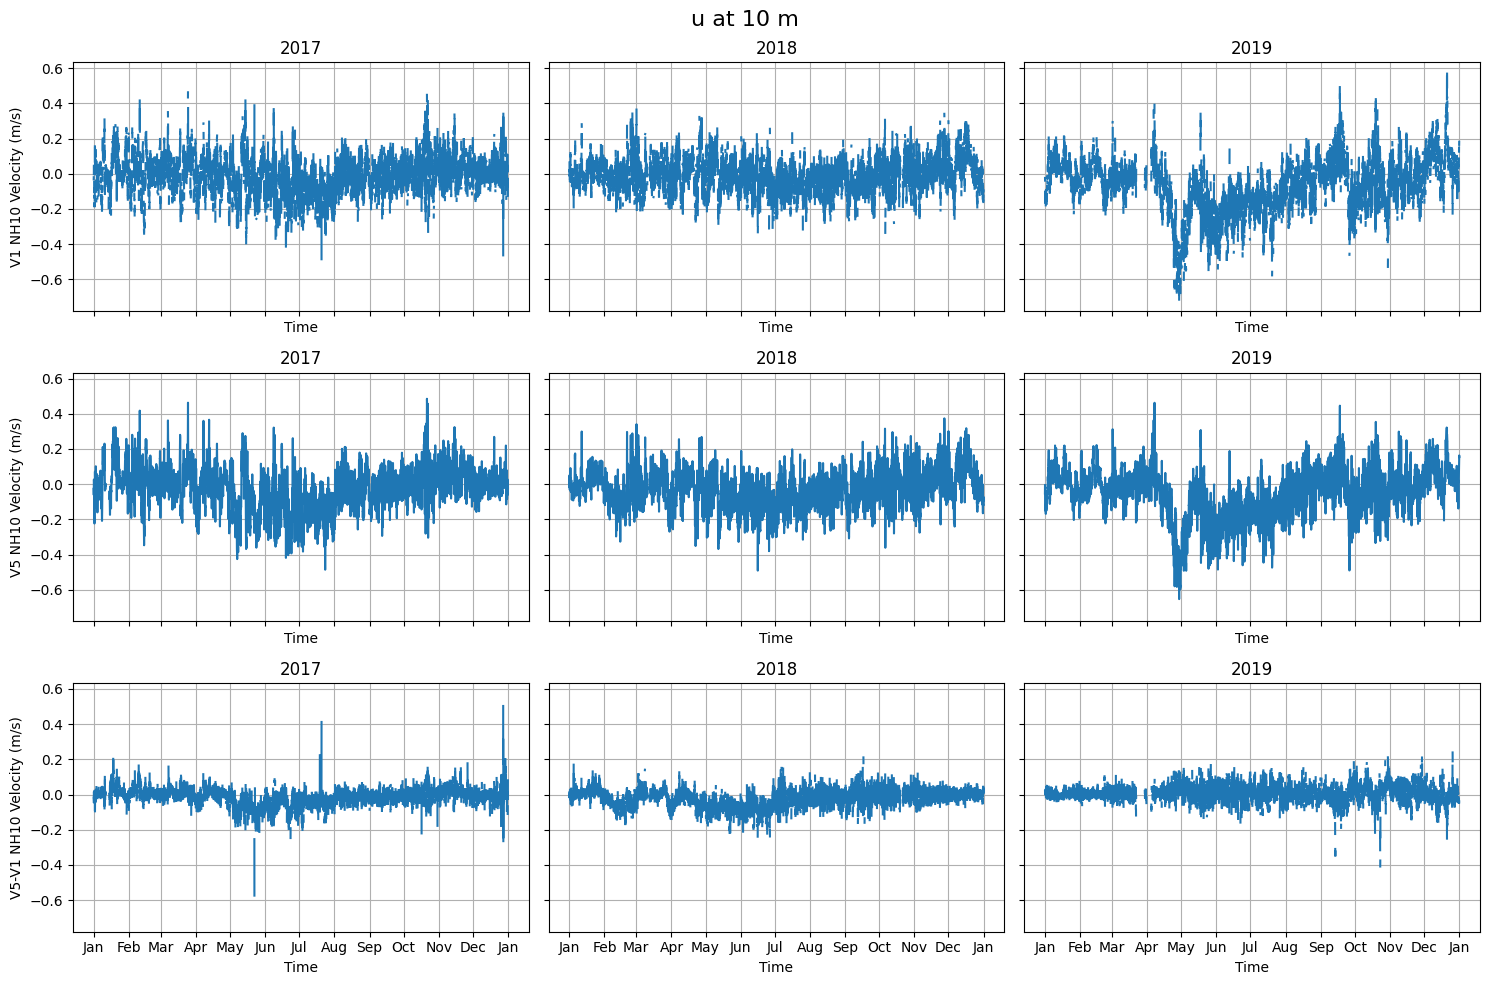

In [14]:
def plot_velocity_v(depth, variable, deployment):
    plt.clf()
    plt.suptitle(f"{variable} at {depth} m")
    fig, (axs1, axs2, axs3) = plt.subplots(
        3, 3, figsize=(15, 10), sharex="col", sharey=True
    )
    if deployment == "GLOBEC (1997-2005)":
        years = range(1999, 2002)
    elif deployment == "NANOOS (2005-2015)":
        years = range(2008, 2011)
    elif deployment == "OOI (2015-Present)":
        years = range(2017, 2020)
    else:
        raise ValueError("Invalid deployment selected.")
    for i, year in enumerate(years):
        ax = axs1[i]
        ax.plot(
            velocity_v1.time.sel(time=str(year)),
            velocity_v1[variable].sel(depth=depth).sel(time=str(year)),
            label=variable,
        )
        ax.set_title(str(year))
        axs1[0].set_ylabel("V1 NH10 Velocity (m/s)")
    for i, year in enumerate(years):
        ax = axs2[i]
        ax.plot(
            velocity_v5.time.sel(time=str(year)),
            velocity_v5[variable].sel(depth=depth).sel(time=str(year)),
            label=variable,
        )
        ax.set_title(str(year))
        axs2[0].set_ylabel("V5 NH10 Velocity (m/s)")
    for i, year in enumerate(years):
        ax = axs3[i]
        vel_v5, vel_v1 = xr.align(
            velocity_v5[variable].sel(depth=depth).sel(time=str(year)),
            velocity_v1[variable].sel(depth=depth).sel(time=str(year)),
            join="outer",
        )
        ax.plot(vel_v5.time, vel_v5 - vel_v1, label=variable)
        ax.set_title(str(year))
        axs3[0].set_ylabel("V5-V1 NH10 Velocity (m/s)")
        print(np.nanmean(np.abs(vel_v5 - vel_v1)), np.nanstd(np.abs(vel_v5 - vel_v1)))
    for ax in zip(axs1, axs2, axs3):
        for a in ax:
            a.xaxis.set_major_locator(mdates.MonthLocator())
            a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
            a.set_xlabel("Time")
            a.grid(True)
    fig.suptitle(f"{variable} at {depth:.0f} m", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_velocity_v(depth_v.value, variable_v.value, deployment_v.value)

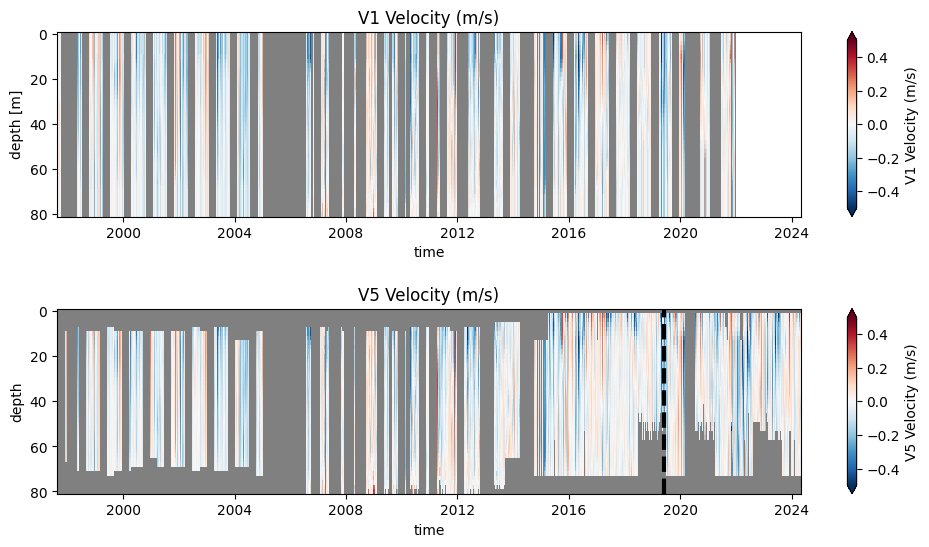

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=0.5)

cmap = plt.get_cmap("RdBu_r")
cmap.set_bad("gray", 1.0)
velocity_v1_u = velocity_v1["u"][::-1].T
velocity_v1_u.plot.pcolormesh(
    ax=axs[0],
    vmin=-0.5,
    vmax=0.5,
    cmap=cmap,
    label="V1 Velocity (m/s)",
    yincrease=False,
    cbar_kwargs={"label": "V1 Velocity (m/s)"},
    xlim=(velocity_v5.time[0], velocity_v5.time[-1]),
)
velocity_v5_u = velocity_v5["u"][::-1].T
velocity_v5_u.plot.pcolormesh(
    ax=axs[1],
    vmin=-0.5,
    vmax=0.5,
    cmap=cmap,
    label="V5 Velocity (m/s)",
    yincrease=False,
    cbar_kwargs={"label": "V5 Velocity (m/s)"},
)
axs[0].set_title("V1 Velocity (m/s)")
axs[1].set_title("V5 Velocity (m/s)")
axs[1].axvline(
    np.datetime64("2019-06-01"),
    color="k",
    linestyle="--",
    label="V5 Deployment Start",
    lw=3,
)

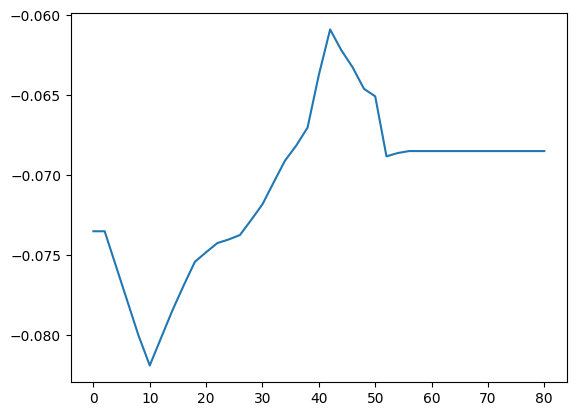

In [10]:
plt.plot(
    velocity_v1.depth,
    velocity_v1["u"]
    .sel(time=slice(np.datetime64("2019-01-01"), np.datetime64("2019-06-01")))
    .mean(dim="time"),
    label="V1",
)